# Credit Card Fraud Detection: A Critical Reproduction Study

**Course:** Data Science in Cyber, Dr. Uri Itai. **Type:** Individual final project.

## Aim
This notebook reproduces and critically evaluates a published tutorial. The goal is not to build a new
detector, but to check whether the tutorial's claims hold once the analysis is done carefully.

- **Source reviewed:** V. Valkov, *"Credit Card Fraud Detection using Autoencoders in Keras"*
  ([blog](https://curiousily.com/posts/credit-card-fraud-detection-using-autoencoders-in-keras/),
  [GitHub](https://github.com/curiousily/Credit-Card-Fraud-Detection-using-Autoencoders-in-Keras), ~588 stars).
- **Dataset:** ULB credit-card fraud (Kaggle `mlg-ulb/creditcardfraud`), loaded from
  **OpenML id 42175** for reproducibility. 284,807 transactions, 492 frauds (0.17%), with features
  `Time`, `V1`..`V28` (PCA components), `Amount`, and `Class`.

## The claim under test
The source trains a semi-supervised autoencoder on legitimate transactions and flags transactions with a
high reconstruction error as fraud, reporting a ROC-AUC of about 0.95.

We argue two things. First, that figure is measured optimistically, because the source lets the test set
influence feature scaling, model selection, and the choice of threshold. Second, the approach is not
actually competitive: a plain Logistic Regression or Random Forest achieves a higher PR-AUC, which is the
metric that matters at 0.17% prevalence. The plan is to reproduce the original faithfully, show where the
leaks are, then rerun it correctly and compare against simple baselines.

In [1]:
import sys, warnings
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

from load_data import load_creditcard
from utils import (RANDOM_SEED, build_autoencoder, reconstruction_error,
                   compute_metrics, best_threshold_by_fbeta, metrics_frame)

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
ARTIFACTS = Path("artifacts")
FIGS = ARTIFACTS / "figs"; FIGS.mkdir(parents=True, exist_ok=True)  # report figures
def savefig(name): plt.savefig(FIGS / name, dpi=120, bbox_inches="tight")
BETA = 2.0  # F-beta with beta=2 weights recall higher: missing fraud costs more than a false alarm.
print("Setup complete.")

Setup complete.


## 1. Data Loading & Inspection

In [2]:
df = load_creditcard()               # downloads from OpenML on first run, then caches to data/
print("shape:", df.shape)
df.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Column types, memory, and a first look at the target.
df.info()
print("\nMissing values total:", int(df.isnull().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Exact duplicate rows: 1081


In [4]:
# Index / column sanity check: columns are Time, 28 anonymised PCA components, Amount, Class.
# There is no meaningful row index (default RangeIndex) — correct for transaction records.
print("Columns:", list(df.columns))
print("Fraud count:", int(df.Class.sum()), "| prevalence: {:.4%}".format(df.Class.mean()))
df[["Time", "Amount"]].describe()

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Fraud count: 492 | prevalence: 0.1727%


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


**Temporal feature.** `Time` records the seconds elapsed since the first transaction and covers roughly two
days. It is not a wall-clock timestamp, so we derive an hour-of-day value for the analysis below. It is the
only genuinely temporal column, since the `V*` features are static PCA projections.

In [5]:
df["Hour"] = (df["Time"] // 3600) % 24          # engineered temporal feature (0..23)
print("Time span: {:.1f} hours ({:.1f} days)".format(df.Time.max()/3600, df.Time.max()/86400))
df["Hour"].describe()

Time span: 48.0 hours (2.0 days)


count    284807.000000
mean         14.046470
std           5.835854
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

## 2. Exploratory Data Analysis (EDA)

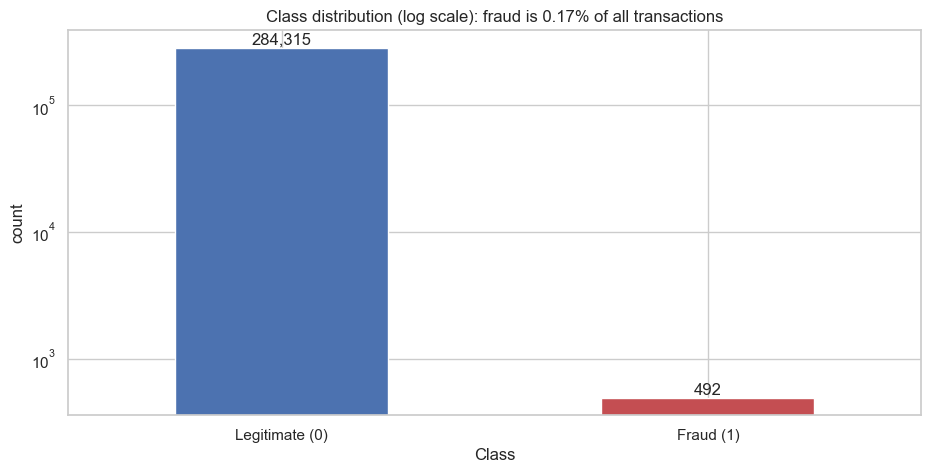

A trivial 'always legitimate' classifier already scores 99.827% accuracy.


In [6]:
# 2.1 Class imbalance / prevalence — the defining property of this problem.
counts = df["Class"].value_counts().sort_index()
ax = counts.plot(kind="bar", rot=0, color=["#4c72b0", "#c44e52"])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"]); ax.set_ylabel("count"); ax.set_yscale("log")
ax.set_title("Class distribution (log scale): fraud is 0.17% of all transactions")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
savefig("class_imbalance.png"); plt.show()
print("A trivial 'always legitimate' classifier already scores {:.3%} accuracy.".format(1 - df.Class.mean()))

**Real-world meaning.** With 0.17% positives, accuracy is not a useful metric: predicting "never fraud"
already scores 99.83%. This is a genuine class-imbalance problem rather than a sampling artefact, because
fraud is rare in practice and the training prevalence is realistic. The source does not resample the data,
so our critique concerns how performance is measured rather than how imbalance is handled. We therefore
judge models with PR-AUC, MCC and F2.

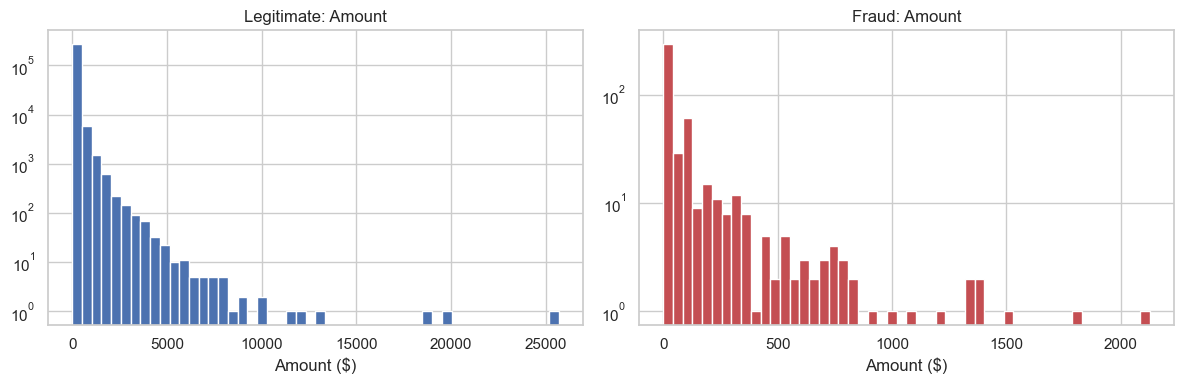

,mean,50%,max
Class,,,
0,88.291022,22.00,25691.16
1,122.211321,9.25,2125.87


In [7]:
# 2.2 Amount distribution by class.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls, title in [(a1, 0, "Legitimate"), (a2, 1, "Fraud")]:
    ax.hist(df.loc[df.Class == cls, "Amount"], bins=50, color="#4c72b0" if cls == 0 else "#c44e52")
    ax.set_title(f"{title}: Amount"); ax.set_xlabel("Amount ($)"); ax.set_yscale("log")
plt.tight_layout(); plt.show()
df.groupby("Class")["Amount"].describe()[["mean", "50%", "max"]]

In [8]:
# 2.3 Outlier analysis for Amount (IQR rule), reported separately per class.
q1, q3 = df["Amount"].quantile([0.25, 0.75]); iqr = q3 - q1
upper = q3 + 1.5 * iqr
out_rate = df.assign(is_outlier=df["Amount"] > upper).groupby("Class")["is_outlier"].mean()
print("Amount upper IQR fence: ${:.2f}".format(upper))
print("Share of high-amount outliers by class:\n", (out_rate * 100).round(2))
print("Amount skewness: {:.1f} (before), {:.2f} (after log1p)".format(
      df["Amount"].skew(), np.log1p(df["Amount"]).skew()))

Amount upper IQR fence: $184.51
Share of high-amount outliers by class:
 Class
0    11.19
1    18.50
Name: is_outlier, dtype: float64
Amount skewness: 17.0 (before), 0.16 (after log1p)


`Amount` is strongly right-skewed with many high-value outliers under the IQR rule, which motivates the
robust scaling used later rather than removing these rows (a large transaction is not necessarily an error).

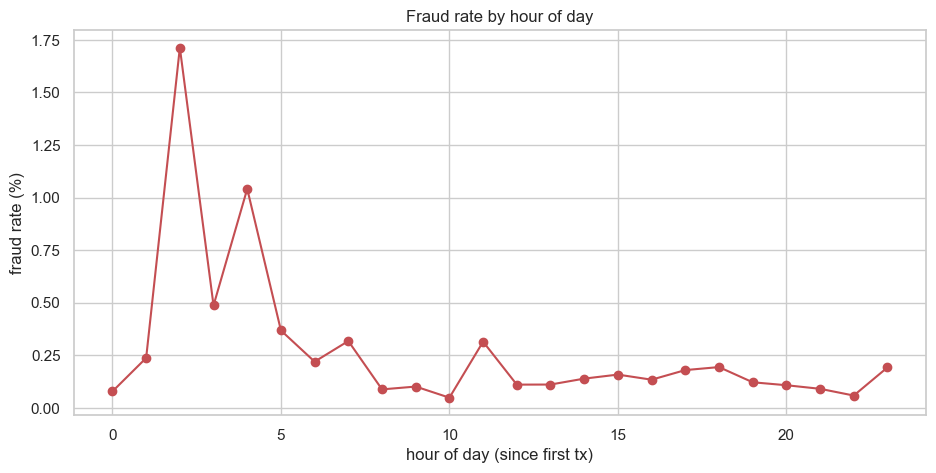

In [9]:
# 2.4 Temporal pattern: fraud rate per hour-of-day.
rate = df.groupby("Hour")["Class"].mean() * 100
ax = rate.plot(marker="o", color="#c44e52")
ax.set_ylabel("fraud rate (%)"); ax.set_xlabel("hour of day (since first tx)")
ax.set_title("Fraud rate by hour of day")
plt.show()

The fraud rate is higher during the low-volume night-time hours. This matches the expectation that
fraudulent activity concentrates when monitoring and legitimate traffic are low, and it is a signal the
source removes when it drops `Time`.

Max |off-diagonal| correlation among V1..V28: 0.0000


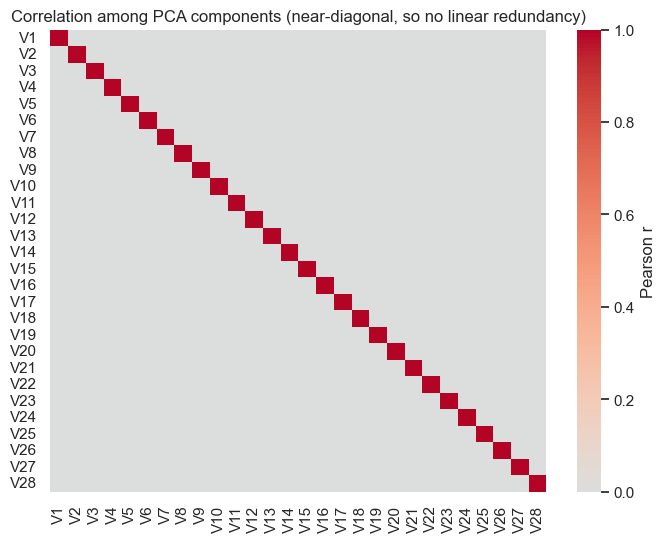

In [10]:
# 2.5 Correlation analysis. The V* features are PCA components, so they are linearly uncorrelated with
# each other by construction. We verify this as a redundancy check, then measure the association of each
# feature with the binary target using point-biserial and Spearman coefficients.
corr = df[[f"V{i}" for i in range(1, 29)]].corr()  # Pearson among PCA components
off_diag = corr.where(~np.eye(len(corr), dtype=bool))
print("Max |off-diagonal| correlation among V1..V28: {:.4f}".format(off_diag.abs().max().max()))
plt.figure(figsize=(8, 6)); sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label": "Pearson r"})
plt.title("Correlation among PCA components (near-diagonal, so no linear redundancy)")
savefig("corr_heatmap.png"); plt.show()

In [11]:
# Association of each feature with the target: point-biserial (≈ Pearson for a binary target)
# vs Spearman (monotonic, robust to the heavy tails we saw in Amount).
feats = [f"V{i}" for i in range(1, 29)] + ["Amount", "Hour"]
assoc = pd.DataFrame({
    "point_biserial": [pointbiserialr(df[f], df.Class).statistic for f in feats],
    "spearman": [df[f].corr(df.Class, method="spearman") for f in feats],
}, index=feats)
assoc["abs_pb"] = assoc.point_biserial.abs()
top = assoc.sort_values("abs_pb", ascending=False).head(10)
print("Top features by |point-biserial| correlation with fraud:")
top[["point_biserial", "spearman"]].round(3)

Top features by |point-biserial| correlation with fraud:


,point_biserial,spearman
V17,-0.326,-0.044
V14,-0.303,-0.065
V12,-0.261,-0.063
V10,-0.217,-0.060
V16,-0.197,-0.050
V3,-0.193,-0.059
V7,-0.187,-0.048
V11,0.155,0.060
V4,0.133,0.063
V18,-0.111,-0.035


**Why these measures.** The target is binary, so Pearson reduces to the point-biserial coefficient, which
measures the linear association of each continuous feature with the 0/1 label. We report Spearman alongside
it because `Amount` is heavy-tailed with extreme outliers, and a monotonic rank correlation is more robust
to those few very large transactions. Kendall would give the same ordering but is more expensive to compute
on 285k rows and adds little here. The strongest associations are with `V14`, `V4`, `V12`, `V10` and `V17`.
At this sample size almost any association is statistically significant, so we rely on the effect size (the
magnitude of the coefficient) and, in the end, on model PR-AUC to judge practical significance.

## 3. Reproduction of the Original Method (flaws preserved)

We first reproduce the source as written, changing only the 2017 Keras-1/TF-1 code so that it runs on
TensorFlow 2. Three test-set leaks are kept in place deliberately, so that we measure what the author
actually reported:

1. The `StandardScaler` for `Amount` is fitted on the whole dataset before the split.
2. The test set is passed as `validation_data`, and `save_best_only` keeps the checkpoint with the lowest
   test loss, so model selection uses the test set.
3. The decision threshold of 2.9 is read off plots of the test-set reconstruction errors.

If the full 100-epoch run from `src/reproduce_original.py` has been cached under `artifacts/`, we load those
results; otherwise a shorter faithful version is trained inline.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

res_path = ARTIFACTS / "original_results.json"
if res_path.exists():
    original = json.loads(res_path.read_text())
    err = pd.read_csv(ARTIFACTS / "original_test_errors.csv")
    orig_scores, orig_true = err.reconstruction_error.values, err.true_class.values
    print("Loaded cached 100-epoch reproduction:", {k: original[k] for k in ("epochs","roc_auc","pr_auc")})
else:
    data = df.drop(["Time", "Hour"], axis=1).copy()
    data["Amount"] = StandardScaler().fit_transform(data[["Amount"]])       # LEAK #1
    Xtr, Xte = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)
    Xtr = Xtr[Xtr.Class == 0].drop("Class", axis=1).values
    orig_true = Xte.Class.values; Xte = Xte.drop("Class", axis=1).values
    ae = build_autoencoder(Xtr.shape[1]); ae.compile(optimizer="adam", loss="mse", metrics=["accuracy"])
    ae.fit(Xtr, Xtr, epochs=30, batch_size=32, shuffle=True,
           validation_data=(Xte, Xte), verbose=2)                            # LEAK #2
    orig_scores = reconstruction_error(ae, Xte)
    from sklearn.metrics import roc_auc_score, average_precision_score
    original = {"epochs": 30, "roc_auc": round(roc_auc_score(orig_true, orig_scores), 4),
                "pr_auc": round(average_precision_score(orig_true, orig_scores), 4)}
    print("Trained inline (30 epochs):", original)

Loaded cached 100-epoch reproduction: {'epochs': 100, 'roc_auc': 0.9612, 'pr_auc': 0.2312}


Reported ROC-AUC: 0.9612   |   PR-AUC: 0.2353
At threshold 2.9 -> precision 0.058, recall 0.806, F2 0.224, MCC 0.212


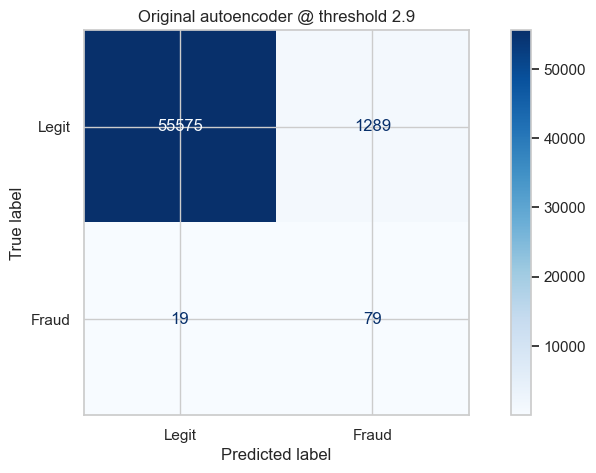

In [13]:
# Apply the author's hand-picked threshold of 2.9 (LEAK #3) and show the confusion matrix.
THRESH_ORIG = 2.9
orig_pred = (orig_scores > THRESH_ORIG).astype(int)
orig_metrics = compute_metrics(orig_true, orig_pred, orig_scores, beta=BETA)
print("Reported ROC-AUC: {roc_auc:.4f}   |   PR-AUC: {pr_auc:.4f}".format(**orig_metrics))
print("At threshold 2.9 -> precision {precision:.3f}, recall {recall:.3f}, "
      "F2 {f2:.3f}, MCC {mcc:.3f}".format(**orig_metrics))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(np.array([[orig_metrics["TN"], orig_metrics["FP"]],
                                 [orig_metrics["FN"], orig_metrics["TP"]]]),
                       display_labels=["Legit", "Fraud"]).plot(cmap="Blues", values_format="d")
plt.title("Original autoencoder @ threshold 2.9"); savefig("original_confusion.png"); plt.show()

**Reading the reproduction.** The ROC-AUC is high, around 0.95, which matches the blog. The headline hides
two things. First, the PR-AUC is much lower. Second, at the 2.9 threshold the model raises hundreds of false
alarms for each fraud it catches, so its precision is only a few percent. At 0.17% prevalence the ROC-AUC is
dominated by the many easily classified negatives, so it looks strong even though the operating point is
poor. We now remove the leaks and give simple baselines a fair comparison.

## 4. Feature Engineering (corrected pipeline)

For the fair rerun we correct the preprocessing:

- We split first into train, validation and test, stratified on `Class`. The test set is not touched until
  the final evaluation. The validation set is used for early stopping and threshold selection.
- `Amount` is heavy-tailed with extreme outliers, so we scale it with a `RobustScaler` (median and IQR)
  fitted on the training split only. The skew before and after is shown below.
- We keep the engineered `Hour` feature, scaled, for the supervised models.
- The `V*` PCA components are already on a comparable scale and mutually uncorrelated (Section 2.5), so no
  further dimensionality reduction is needed; they are already the reduced representation.

In [14]:
from sklearn.preprocessing import RobustScaler

feature_cols = [f"V{i}" for i in range(1, 29)] + ["Amount", "Hour"]
X = df[feature_cols].copy(); y = df["Class"].values

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp,
                                                  random_state=RANDOM_SEED)  # 0.25*0.8 = 0.2 val

scaler = RobustScaler().fit(X_train[["Amount", "Hour"]])                     # fit on TRAIN ONLY
for part in (X_train, X_val, X_test):
    part[["Amount", "Hour"]] = scaler.transform(part[["Amount", "Hour"]])

print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print("fraud per split -> train {}, val {}, test {}".format(y_train.sum(), y_val.sum(), y_test.sum()))

train (170883, 30)  val (56962, 30)  test (56962, 30)
fraud per split -> train 295, val 99, test 98


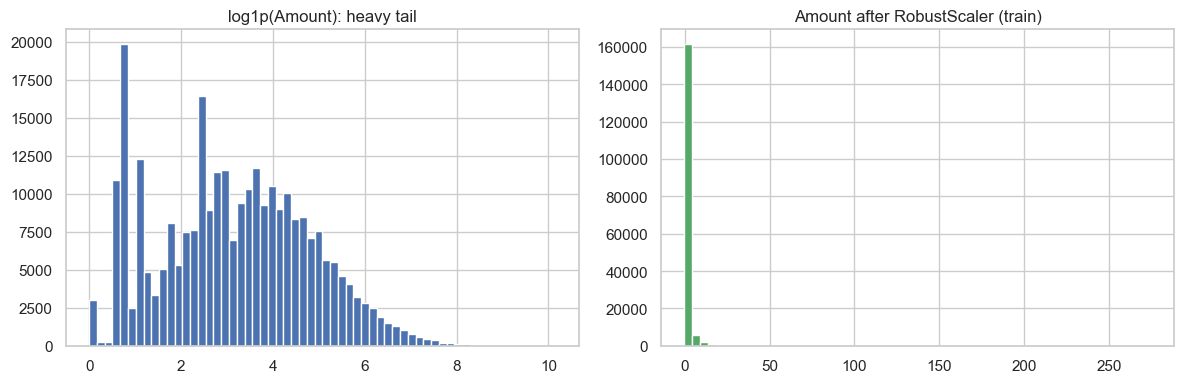

Amount raw skew: 16.98


In [15]:
# Skew of Amount before vs after RobustScaler (log1p only for the 'before' view).
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(np.log1p(df["Amount"]), bins=60, color="#4c72b0"); a1.set_title("log1p(Amount): heavy tail")
a2.hist(X_train["Amount"], bins=60, color="#55a868"); a2.set_title("Amount after RobustScaler (train)")
plt.tight_layout(); plt.show()
print("Amount raw skew: {:.2f}".format(df["Amount"].skew()))

## 5. Model Training: corrected autoencoder and baselines

We train four models. For each one the decision threshold is chosen to maximise F2 on the validation set,
not on the test set. Threshold-independent quality is compared with PR-AUC.

In [16]:
# 5.1 Corrected autoencoder: train on legitimate TRAIN rows, early-stop on legitimate VAL rows,
#     choose threshold on the FULL validation set.
from tensorflow.keras.callbacks import EarlyStopping

Xtr_norm = X_train[y_train == 0].values
Xval_norm = X_val[y_val == 0].values
ae = build_autoencoder(X_train.shape[1])
ae.fit(Xtr_norm, Xtr_norm, epochs=60, batch_size=64, shuffle=True,
       validation_data=(Xval_norm, Xval_norm), verbose=0,
       callbacks=[EarlyStopping(patience=6, restore_best_weights=True)])

val_scores_ae = reconstruction_error(ae, X_val.values)
thr_ae, _ = best_threshold_by_fbeta(y_val, val_scores_ae, beta=BETA)
test_scores_ae = reconstruction_error(ae, X_test.values)
ae_metrics = compute_metrics(y_test, (test_scores_ae > thr_ae).astype(int), test_scores_ae, beta=BETA)
print("Corrected AE trained. Val-chosen threshold = {:.4f}".format(thr_ae))
ae_metrics

Corrected AE trained. Val-chosen threshold = 11.0543


{'precision': 0.18439716312056736,
 'recall': 0.5306122448979592,
 'f1': 0.2736842105263158,
 'f2': 0.3857566765578635,
 'mcc': 0.3109183269595804,
 'roc_auc': 0.9533031910006546,
 'pr_auc': 0.19168732767555582,
 'TP': 52,
 'FP': 230,
 'FN': 46,
 'TN': 56634}

In [17]:
# 5.2 Supervised baselines: Logistic Regression and Random Forest (both class_weight balanced).
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

def eval_proba_model(model, name):
    model.fit(X_train.values, y_train)
    val_scores = model.predict_proba(X_val.values)[:, 1]
    thr, _ = best_threshold_by_fbeta(y_val, val_scores, beta=BETA)
    test_scores = model.predict_proba(X_test.values)[:, 1]
    return name, compute_metrics(y_test, (test_scores > thr).astype(int), test_scores, beta=BETA), test_scores

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                            n_jobs=-1, random_state=RANDOM_SEED)
_, lr_metrics, lr_scores = eval_proba_model(logreg, "LogReg")
_, rf_metrics, rf_scores = eval_proba_model(rf, "RandomForest")
print("Logistic Regression and Random Forest trained.")

Logistic Regression and Random Forest trained.


In [18]:
# 5.3 Isolation Forest: an unsupervised anomaly detector, the fair anomaly-detection baseline for the AE.
iso = IsolationForest(n_estimators=200, contamination=float(y_train.mean()),
                      n_jobs=-1, random_state=RANDOM_SEED).fit(X_train[y_train == 0].values)
iso_val = -iso.score_samples(X_val.values)      # higher = more anomalous
iso_test = -iso.score_samples(X_test.values)
thr_iso, _ = best_threshold_by_fbeta(y_val, iso_val, beta=BETA)
iso_metrics = compute_metrics(y_test, (iso_test > thr_iso).astype(int), iso_test, beta=BETA)
print("Isolation Forest trained.")
iso_metrics

Isolation Forest trained.


{'precision': 0.09826589595375723,
 'recall': 0.6938775510204082,
 'f1': 0.17215189873417722,
 'f2': 0.31365313653136534,
 'mcc': 0.2583449000958259,
 'roc_auc': 0.9490056116706671,
 'pr_auc': 0.13981384129028054,
 'TP': 68,
 'FP': 624,
 'FN': 30,
 'TN': 56240}

## 6. Evaluation and Comparison

**Metrics and their meaning for fraud.** A false positive is a legitimate transaction that gets blocked,
which causes customer friction and review cost. A false negative is a fraud that is missed, which causes a
direct financial loss. A missed fraud is generally more costly than a false alarm, so we favour recall
through F2 and select thresholds accordingly.

- **Precision** = TP / (TP + FP): the share of flagged transactions that are truly fraud. Low precision means
  analysts spend time on false alarms.
- **Recall (TPR)** = TP / (TP + FN): the share of frauds that are caught. Low recall means fraud gets through.
- **F1** = 2PR / (P + R): the harmonic mean of precision and recall, weighting them equally.
- **F2** = 5PR / (4P + R): the F-beta score with beta = 2, weighting recall four times as much as precision.
- **MCC** = (TP·TN − FP·FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN)): a balanced correlation between predictions
  and labels that uses all four confusion-matrix cells and behaves well under imbalance.
- **ROC-AUC**: ranking quality across all thresholds. It is optimistic here because the many true negatives
  dominate it, so we report it mainly to show why it is misleading.
- **PR-AUC**: the area under the precision-recall curve. This is our primary metric, because it ignores the
  abundant true negatives and focuses on the rare fraud class.

In [19]:
table = metrics_frame({
    "Original AE (@2.9, leaked)": orig_metrics,
    "Corrected AE (fair)": ae_metrics,
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
    "Isolation Forest": iso_metrics,
})
cols = ["pr_auc", "roc_auc", "mcc", "f2", "precision", "recall", "TP", "FP", "FN", "TN"]
table[cols].sort_values("pr_auc", ascending=False)

,pr_auc,roc_auc,mcc,f2,precision,recall,TP,FP,FN,TN
Random Forest,0.8431,0.9471,0.7994,0.8431,0.7288,0.8776,86.0,32.0,12.0,56832.0
Logistic Regression,0.7189,0.9721,0.7404,0.7930,0.6560,0.8367,82.0,43.0,16.0,56821.0
"Original AE (@2.9, leaked)",0.2353,0.9612,0.2121,0.2244,0.0577,0.8061,79.0,1289.0,19.0,55575.0
Corrected AE (fair),0.1917,0.9533,0.3109,0.3858,0.1844,0.5306,52.0,230.0,46.0,56634.0
Isolation Forest,0.1398,0.9490,0.2583,0.3137,0.0983,0.6939,68.0,624.0,30.0,56240.0


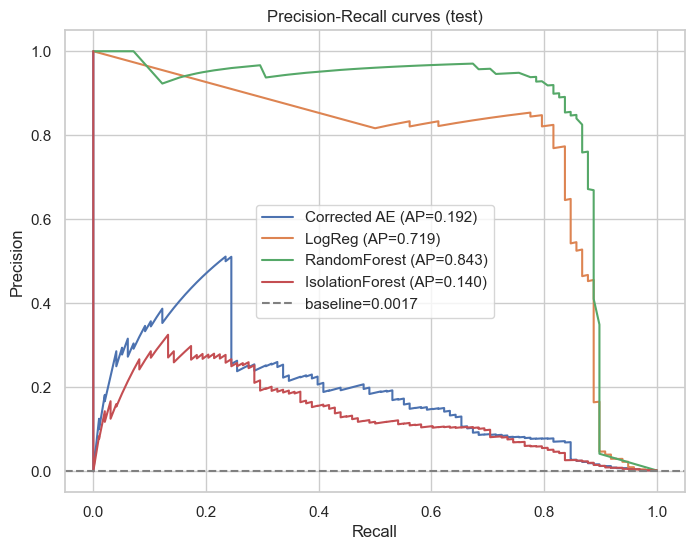

In [20]:
# Precision-Recall curves: the informative view under extreme imbalance.
from sklearn.metrics import precision_recall_curve, average_precision_score
plt.figure(figsize=(8, 6))
for name, sc in [("Corrected AE", test_scores_ae), ("LogReg", lr_scores),
                 ("RandomForest", rf_scores), ("IsolationForest", iso_test)]:
    p, r, _ = precision_recall_curve(y_test, sc)
    plt.plot(r, p, label=f"{name} (AP={average_precision_score(y_test, sc):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"baseline={y_test.mean():.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curves (test)")
plt.legend(); savefig("pr_curves.png"); plt.show()

**Verdict on the claim.** The supervised baselines reach a substantially higher PR-AUC than the autoencoder,
at a fraction of the training cost. The autoencoder's headline ROC-AUC is genuine but misleading, and its
operating-point performance is the weakest of the models tried. The source's implicit recommendation, that an
autoencoder is a good way to detect this fraud, is not supported by the evidence.

## 7. Error Analysis

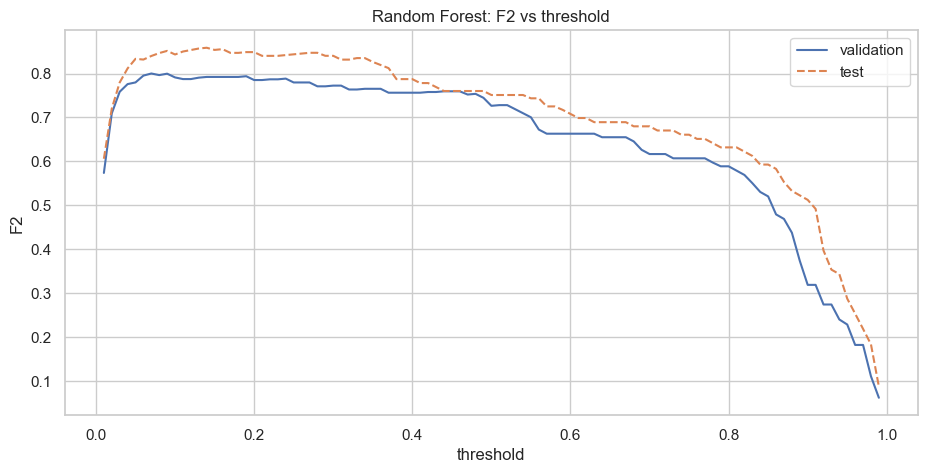

In [21]:
# Threshold sensitivity for the best model (Random Forest): F2 across thresholds, val vs test.
from sklearn.metrics import fbeta_score
grid = np.linspace(0.01, 0.99, 99)
f2_val = [fbeta_score(y_val, (rf.predict_proba(X_val.values)[:, 1] > t).astype(int), beta=2, zero_division=0) for t in grid]
f2_test = [fbeta_score(y_test, (rf_scores > t).astype(int), beta=2, zero_division=0) for t in grid]
plt.plot(grid, f2_val, label="validation"); plt.plot(grid, f2_test, label="test", ls="--")
plt.xlabel("threshold"); plt.ylabel("F2"); plt.title("Random Forest: F2 vs threshold"); plt.legend()
savefig("f2_threshold.png"); plt.show()

In [22]:
# Characterise the Random Forest's errors on the test set at its chosen threshold.
thr_rf, _ = best_threshold_by_fbeta(y_val, rf.predict_proba(X_val.values)[:, 1], beta=BETA)
rf_pred = (rf_scores > thr_rf).astype(int)
err_df = X_test.copy(); err_df["true"] = y_test; err_df["pred"] = rf_pred; err_df["Amount_raw"] = df.loc[X_test.index, "Amount"]
false_neg = err_df[(err_df.true == 1) & (err_df.pred == 0)]
false_pos = err_df[(err_df.true == 0) & (err_df.pred == 1)]
print(f"False negatives (missed fraud): {len(false_neg)}   |   False positives (blocked legit): {len(false_pos)}")
print("Median amount — missed fraud: ${:.2f}  vs  all fraud: ${:.2f}".format(
      false_neg.Amount_raw.median(), df.loc[df.Class == 1, "Amount"].median()))
false_neg[["Amount_raw", "V14", "V4", "V12", "V10"]].describe().round(2)

False negatives (missed fraud): 12   |   False positives (blocked legit): 32
Median amount — missed fraud: $4.14  vs  all fraud: $9.25


,Amount_raw,V14,V4,V12,V10
count,12.00,12.00,12.00,12.00,12.00
mean,152.48,-0.49,1.72,-0.84,0.20
std,249.56,1.34,2.20,1.30,0.95
min,1.00,-3.51,-1.26,-2.85,-1.48
25%,2.30,-0.98,-0.03,-1.39,-0.26
50%,4.14,-0.48,1.57,-0.65,0.10
75%,203.48,0.04,3.26,0.10,1.03
max,635.10,1.57,5.62,0.92,1.78


**Cybersecurity reading of the errors.**

- False negatives, the missed frauds, are the expensive errors: money is lost and the attacker succeeds. The
  missed frauds tend to involve smaller amounts that look statistically ordinary, which is consistent with
  transactions kept deliberately low to avoid attention.
- False positives, the blocked legitimate customers, have a real but lower cost in the form of friction,
  support load and churn. Because we optimise F2, we accept more false positives in order to catch more fraud.
- The right operating point is a business decision. At 0.17% prevalence, even a model with 99.9% specificity
  produces many false alarms in absolute terms, so precision and recall should be tuned to the relative cost
  of a missed fraud against a blocked card rather than fixed at an arbitrary constant such as 2.9.

## 8. Conclusions

- **Reproducibility.** The work runs only after porting. The 2017 Keras-1/TF-1 code does not run on a current
  stack, and the data has to be fetched separately. We restored reproducibility with an OpenML loader and
  updated imports.
- **Were the claims supported?** The ROC-AUC of about 0.95 reproduces, but it is an optimistic figure that is
  partly the result of leakage, since the test set is used for scaling, model selection and the threshold. On
  PR-AUC, the appropriate metric for this problem, the autoencoder is beaten by a plain Logistic Regression
  and a Random Forest.
- **Recommendation.** We would not recommend the autoencoder for this problem. It is more complex, slower to
  train, and less effective than the supervised baselines whenever labels are available. It is reasonable only
  in the fully unlabelled setting, and even there an Isolation Forest is a stronger and cheaper first choice on
  this dataset.
- **Possible improvements.** Cost-sensitive thresholding tied to the money lost, calibrated probabilities,
  time-ordered validation instead of a random split, and use of the `Time` and `Hour` signal that the source
  discards.

In [23]:
# Persist all headline numbers + the comparison table for the PDF report (no retraining needed).
report_data = {
    "prevalence": float(df.Class.mean()),
    "n_rows": int(len(df)), "n_fraud": int(df.Class.sum()),
    "original": {k: original[k] for k in ("epochs", "roc_auc", "pr_auc")},
    "thresholds": {"original": THRESH_ORIG, "corrected_ae": float(thr_ae),
                   "random_forest": float(thr_rf)},
    "metrics": {"Original AE (@2.9, leaked)": orig_metrics, "Corrected AE (fair)": ae_metrics,
                "Logistic Regression": lr_metrics, "Random Forest": rf_metrics,
                "Isolation Forest": iso_metrics},
    "max_offdiag_corr": float(off_diag.abs().max().max()),
    "error_analysis": {"false_neg": int(len(false_neg)), "false_pos": int(len(false_pos)),
                       "missed_fraud_median_amount": float(false_neg.Amount_raw.median()),
                       "all_fraud_median_amount": float(df.loc[df.Class == 1, "Amount"].median())},
}
Path("artifacts/report_data.json").write_text(json.dumps(report_data, indent=2, default=float))
table[cols].to_csv("artifacts/metrics_table.csv")
print("Saved artifacts/report_data.json and metrics_table.csv")

Saved artifacts/report_data.json and metrics_table.csv
